# Import

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

import joblib
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from physics.Iso_data_handler import Iso_data_handler
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator

In [3]:
pre_path = "../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_B/final_models/"
path_to_predictions = pre_path + "predictions/model_B/final_models/"
path_to_models = 'model/final_models/model_B/MIST/'
output_parameters = ['T_eff', 'log_g', 'radius']
categories_name = ["phase"]

# Data preparation

In [4]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


In [5]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})

In [6]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'metallicity', 'star_mass'], 
                               y_cols=['log_Teff', 'log_g', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the log_Teff parameter : 3.344668191350628 - 5.378801600728572
Median value in train data for the log_Teff parameter: 3.976722754899366
Mean value in train data for the log_Teff parameter: 4.028639708216513

Range in train data for the log_g parameter : -1.0828963170617296 - 6.259434356871683
Median value in train data for the log_g parameter: 3.852761890388139
Mean value in train data for the log_g parameter: 3.508503471076473

Range in train data for the log_R parameter : -0.9974628481553472 - 3.129269620812593
Median value in train data for the log_R parameter: 0.7005259212303901
Mean value in train data for the log_R parameter: 0.7346615625058007

Testing set statistics:
Range in test data for the log_Teff parameter : 3.3447003632081813 - 5.3787504733463445
Median value in test data for the log_Teff parameter: 3.9741415586935043
Mean value in test data for the log_Teff parameter: 4.027301245585765

Range in test data for the log_g pa

In [7]:
X_train_quantile, X_ivs_quantile = Data_preparator.scale_data(X_train, X_ivs, "quantile")

print(X_train_quantile.shape, X_ivs_quantile.shape)

(472953, 3) (157652, 3)


# Getting the final evaluations

## Random forest

In [7]:
tag = "scale_quantile"


scale_quantile train data :
Training the model...
Evaluating predictions...
no negative values

T_eff results for the phase category with a value of 0.0
  value range :  3.3447003632081813 - 4.903113097363014
  RVE :  0.9831832629624273
  RMSE :  0.04589324438357916
  MAE :  0.010638532776531978
  MedAE :  0.0019012284152055692
  CORR :  0.9915720002680878
  MAX_ER :  0.821478177138117
  Percentiles : 
    75th percentile :  0.004604418096747276
    90th percentile :  0.01228203756479927
    95th percentile :  0.03261065862485376
    99th percentile :  0.22707118649207544

T_eff results for the phase category with a value of 2.0
  value range :  3.424526073183654 - 4.703420536058761
  RVE :  0.9849388030457125
  RMSE :  0.03887675212825012
  MAE :  0.018608502759492253
  MedAE :  0.005411764246338713
  CORR :  0.9924810796715235
  MAX_ER :  0.5585873550487315
  Percentiles : 
    75th percentile :  0.01593948267681422
    90th percentile :  0.058152521693922
    95th percentile :  0.0

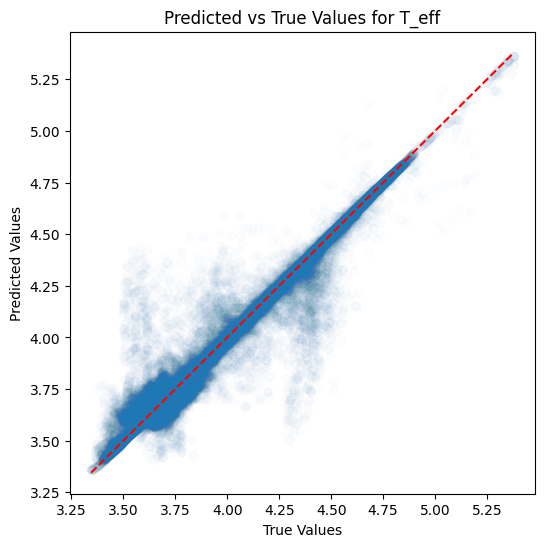

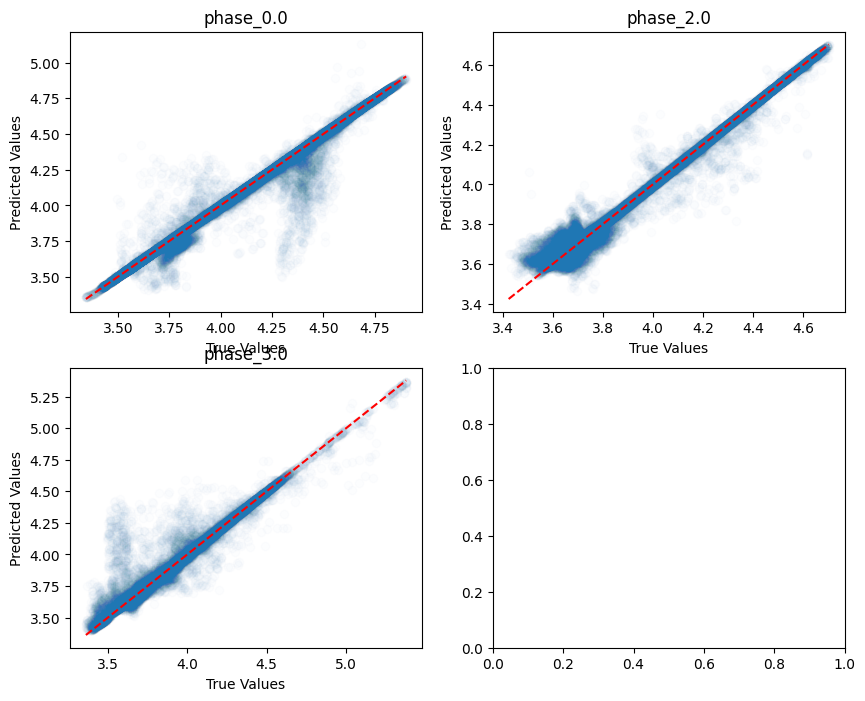

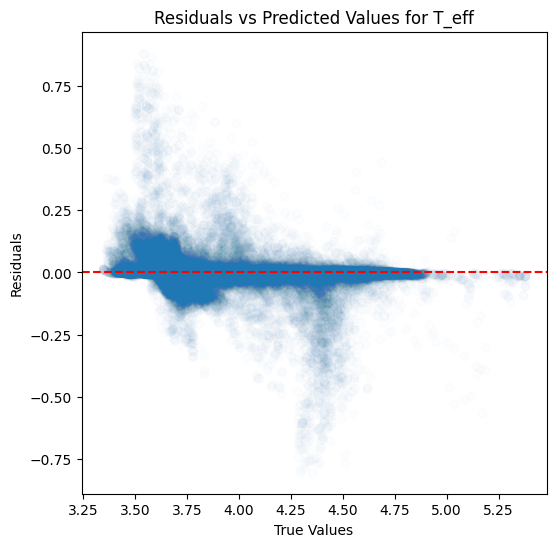

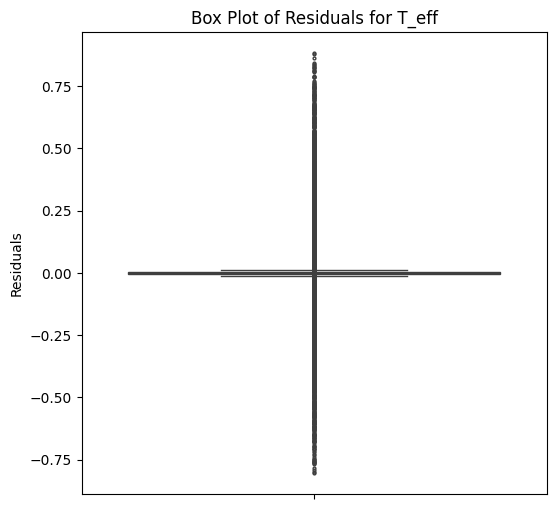

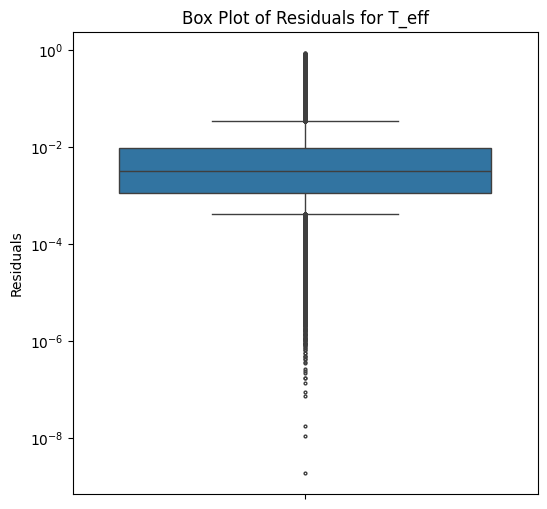

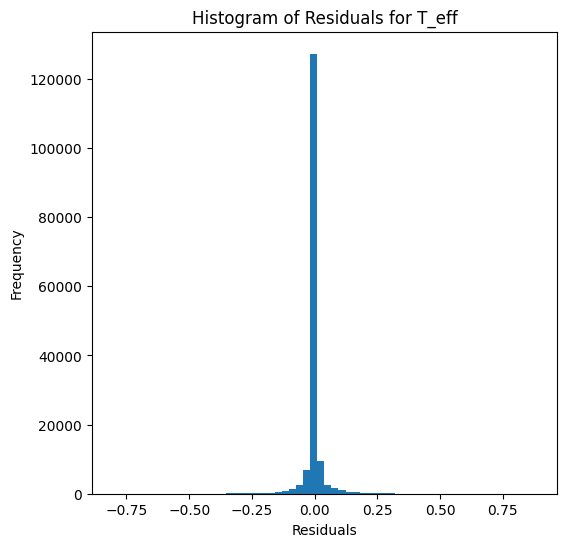

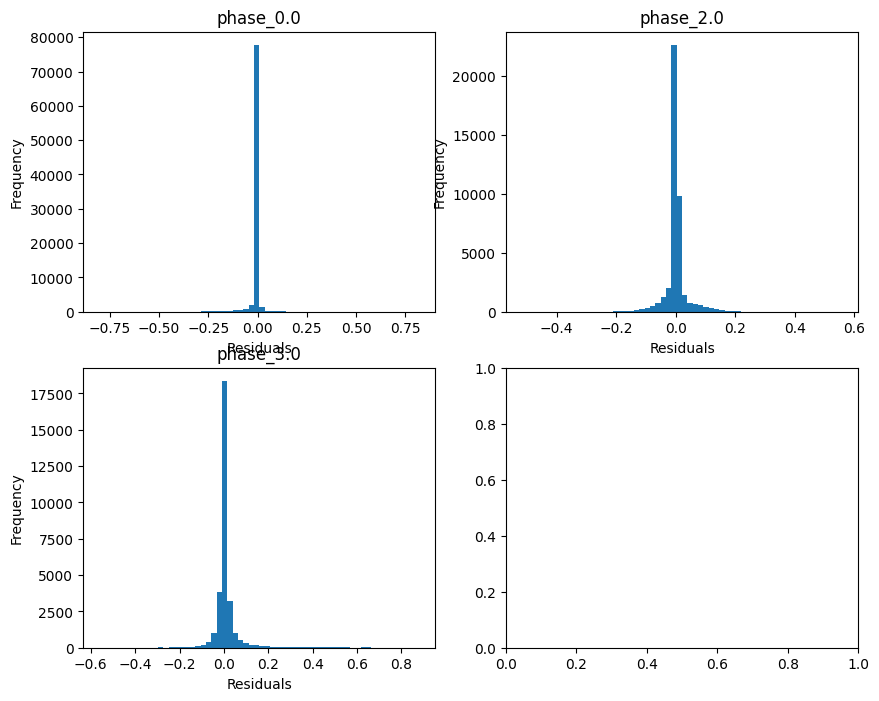

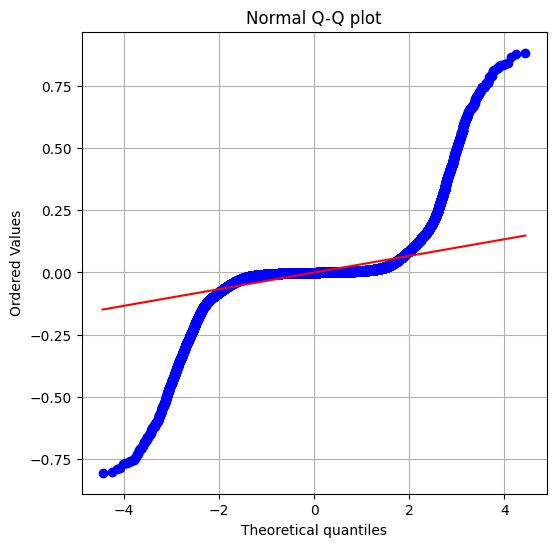

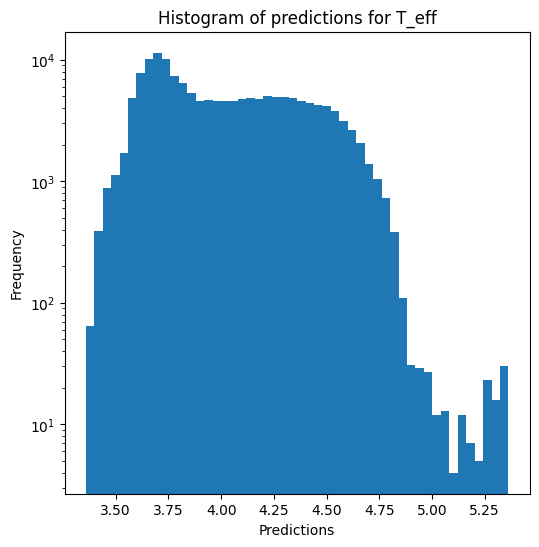

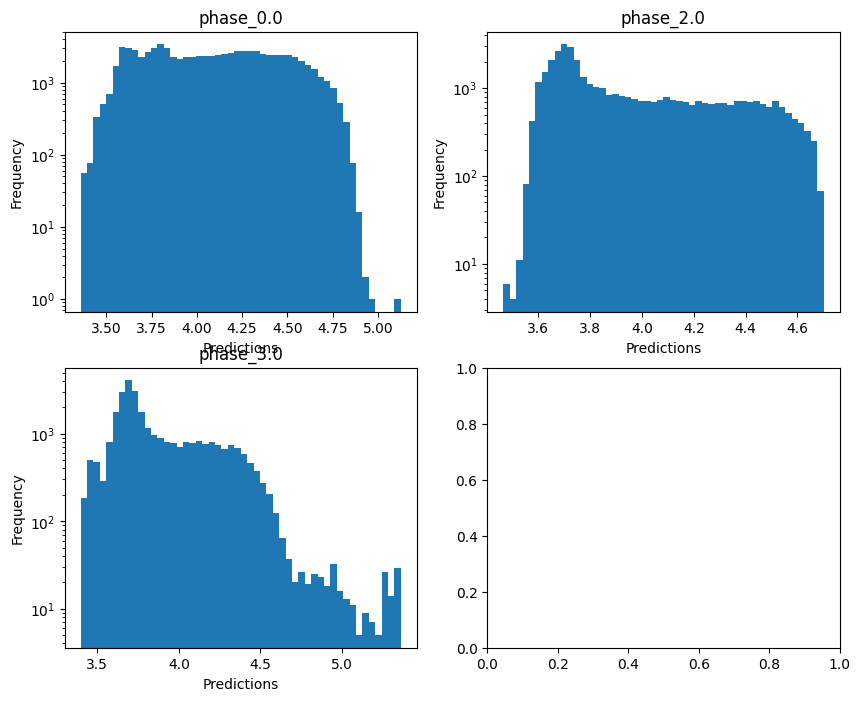


log_g results for the phase category with a value of 0.0
  value range :  -0.5973100835175252 - 5.433094523832443
  RVE :  0.7543165913351924
  RMSE :  0.3124882449076653
  MAE :  0.06813032482368192
  MedAE :  0.006119674106422224
  CORR :  0.8973383524722158
  MAX_ER :  5.168569272033283
  Percentiles : 
    75th percentile :  0.019714467053153606
    90th percentile :  0.061797606038655285
    95th percentile :  0.1838526134202854
    99th percentile :  1.737033078286522

log_g results for the phase category with a value of 2.0
  value range :  -0.3287802371627256 - 4.403503445748651
  RVE :  0.596607364191519
  RMSE :  0.5793914220921692
  MAE :  0.25784759398188445
  MedAE :  0.02315949925206029
  CORR :  0.7752996993920123
  MAX_ER :  4.175207384143549
  Percentiles : 
    75th percentile :  0.16107851633837122
    90th percentile :  0.995725190915235
    95th percentile :  1.4826934583574538
    99th percentile :  2.2901805353340903

log_g results for the phase category with a 

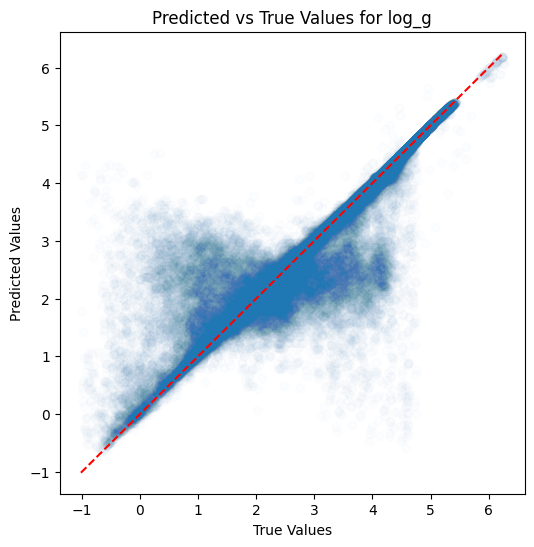

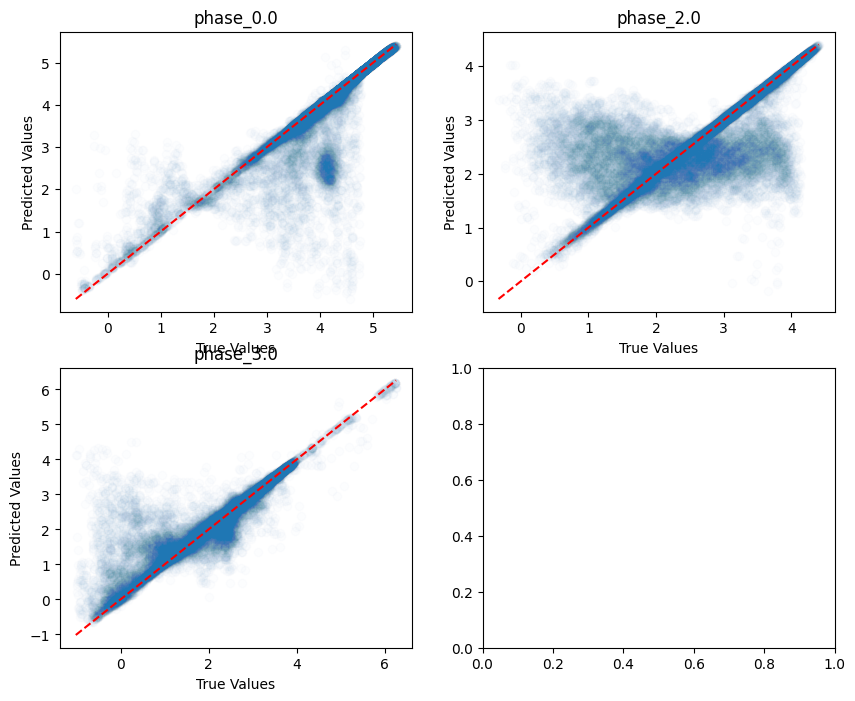

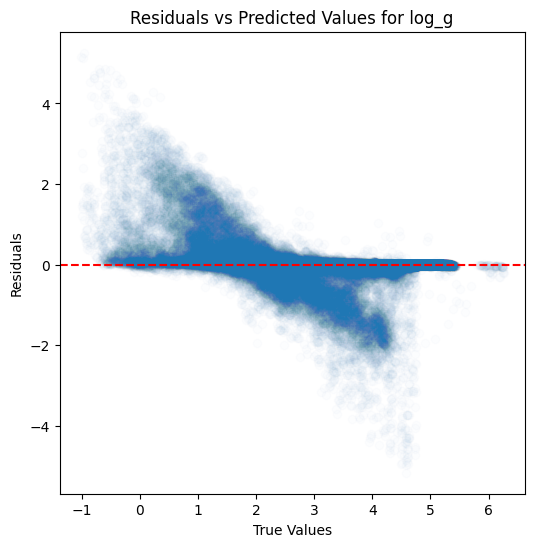

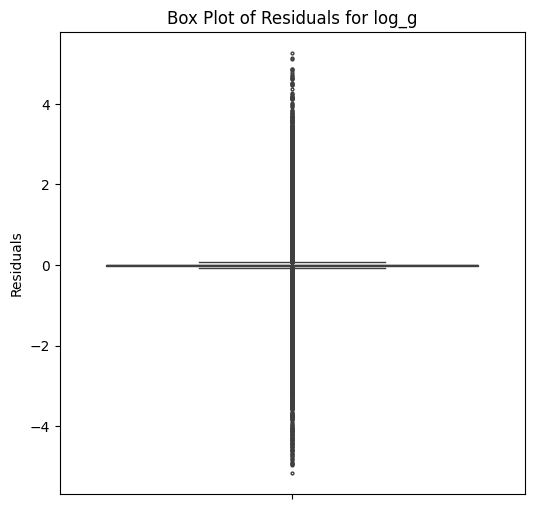

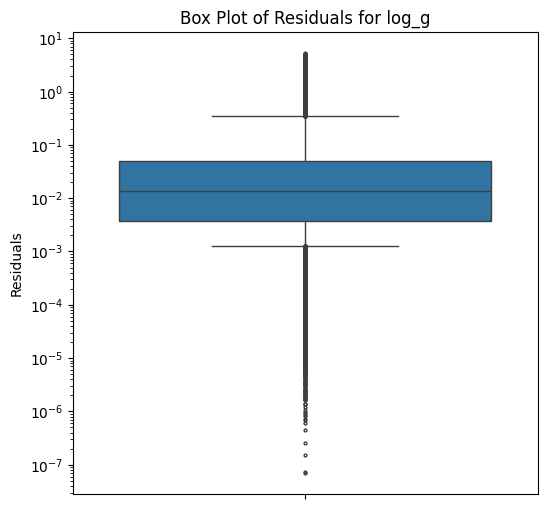

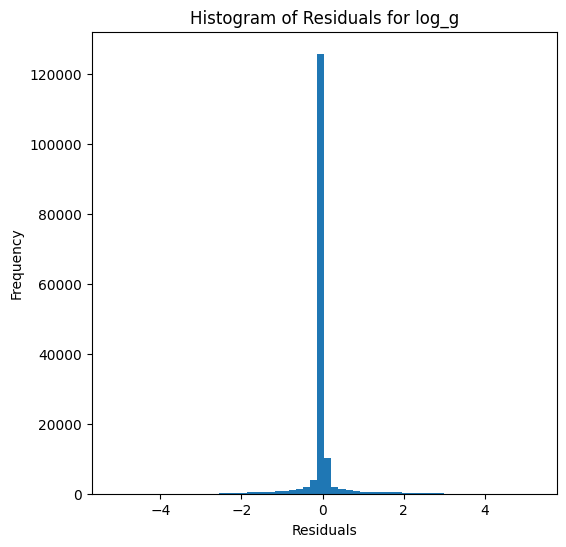

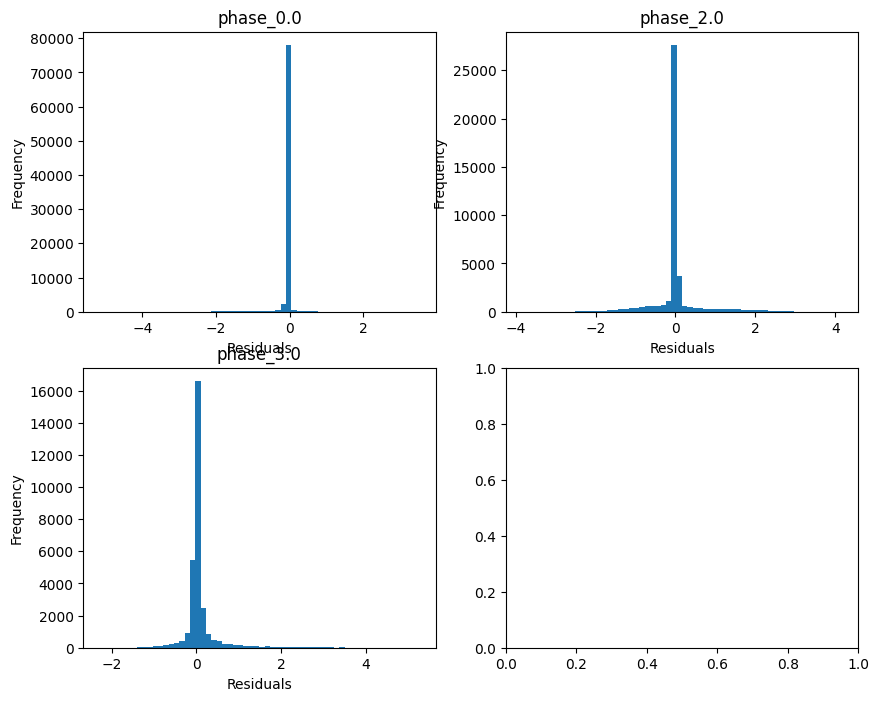

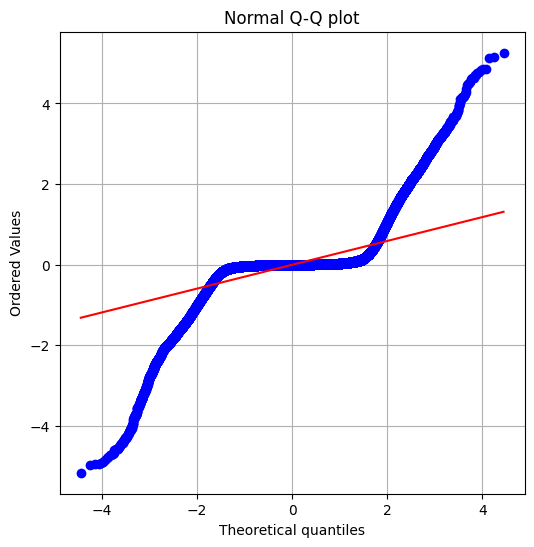

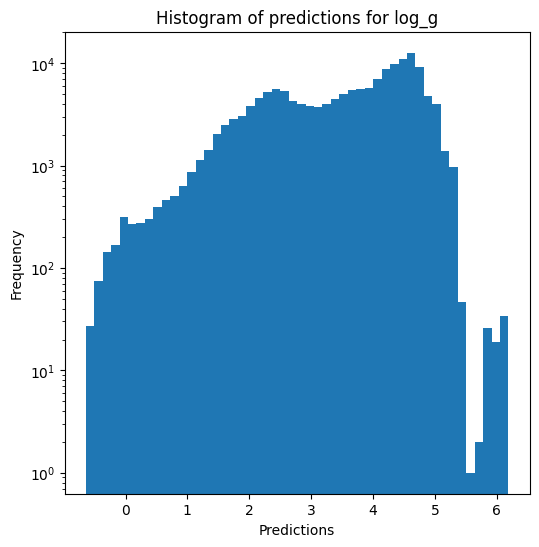

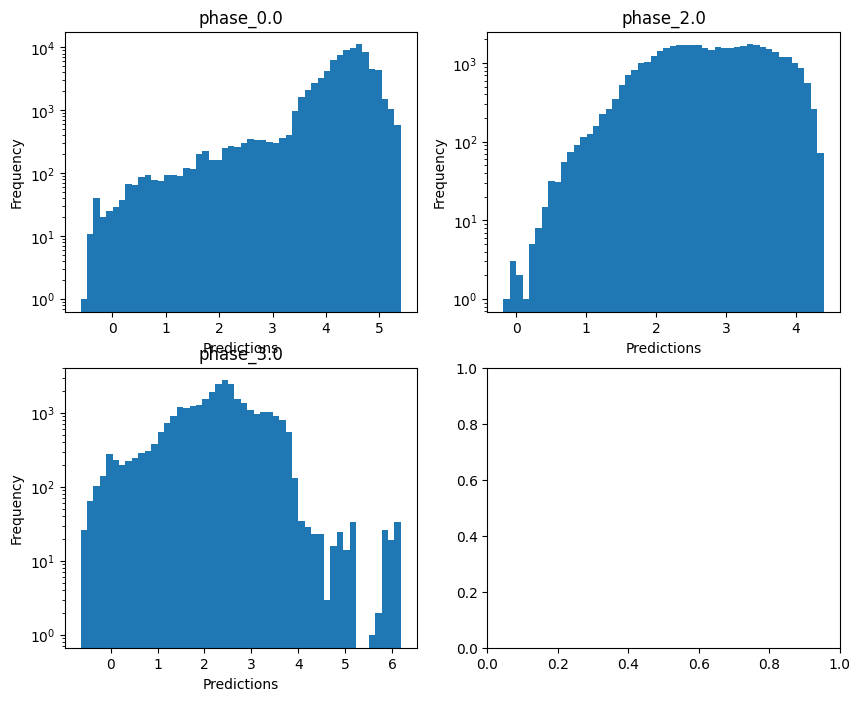

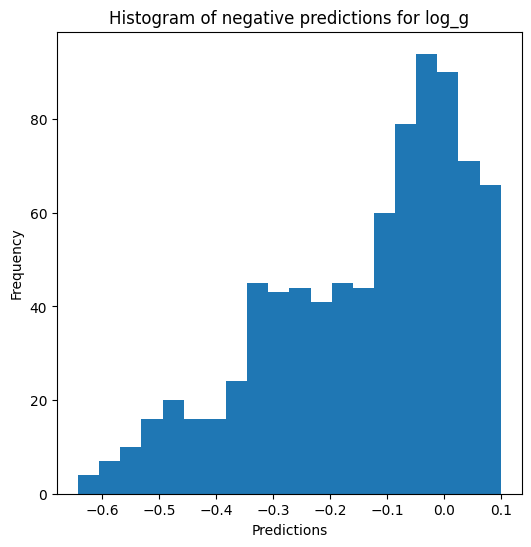


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.926097110224193
  RMSE :  0.1564404910449827
  MAE :  0.034985771768112225
  MedAE :  0.004087939172058321
  CORR :  0.9648918805312173
  MAX_ER :  2.5857707943833654
  Percentiles : 
    75th percentile :  0.011556624704175268
    90th percentile :  0.032370787426312296
    95th percentile :  0.0924610178458244
    99th percentile :  0.8693653426287006

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.652225572867988
  RMSE :  0.2896920327373445
  MAE :  0.12892578583071748
  MedAE :  0.01159350318077812
  CORR :  0.8117385464160786
  MAX_ER :  2.0865335966363356
  Percentiles : 
    75th percentile :  0.08051316899929528
    90th percentile :  0.4978675774719454
    95th percentile :  0.7412417000905971
    99th percentile :  1.1451715068557593

radius results for the phase category w

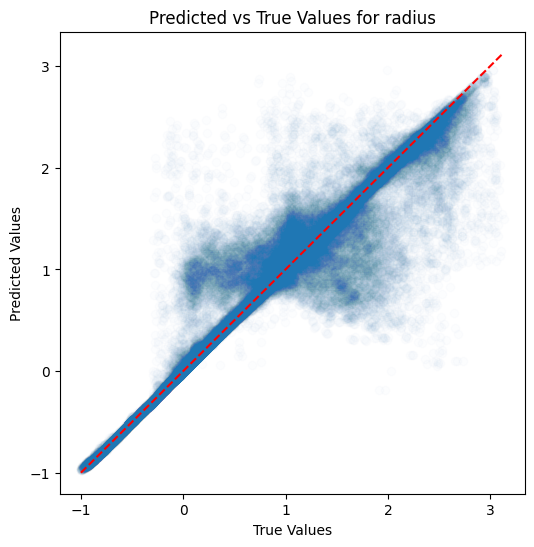

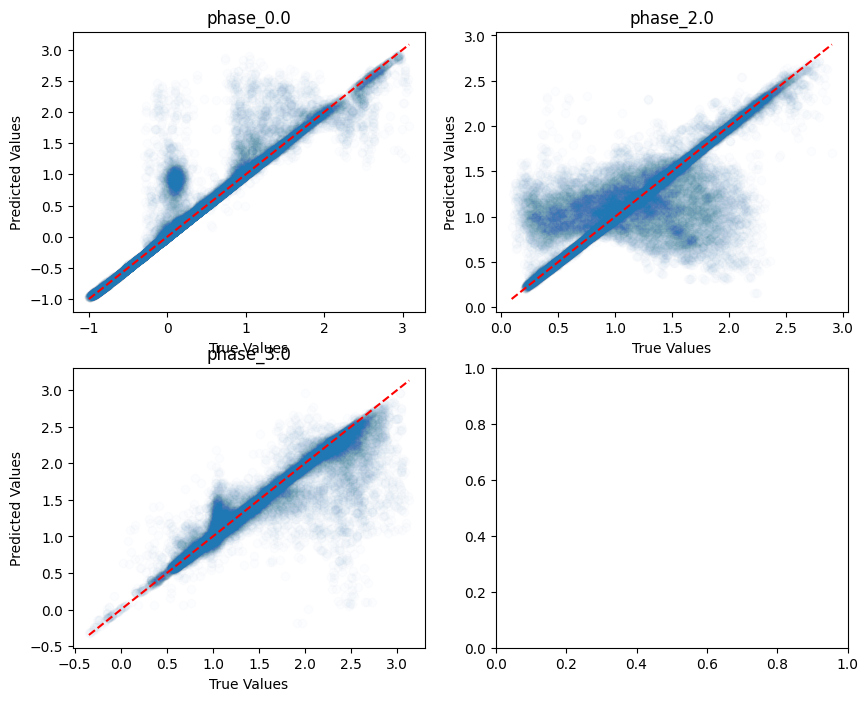

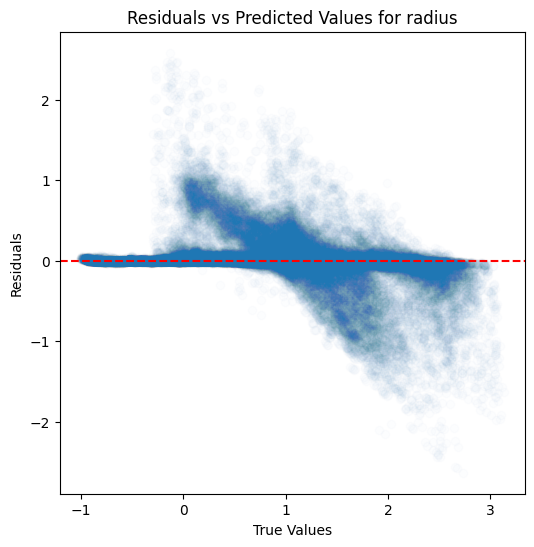

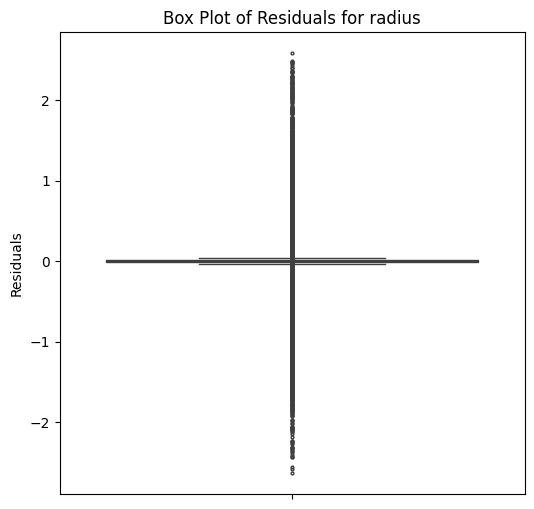

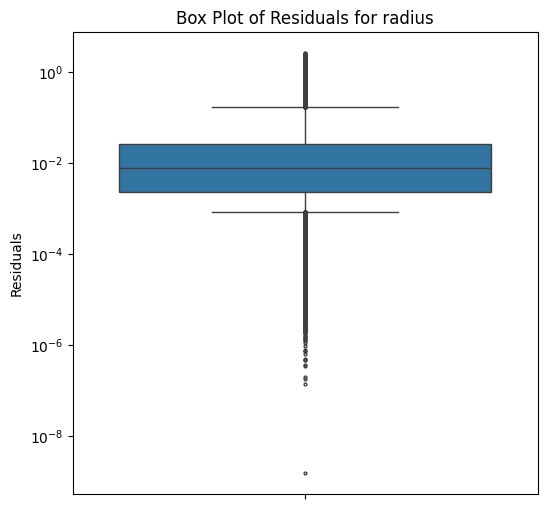

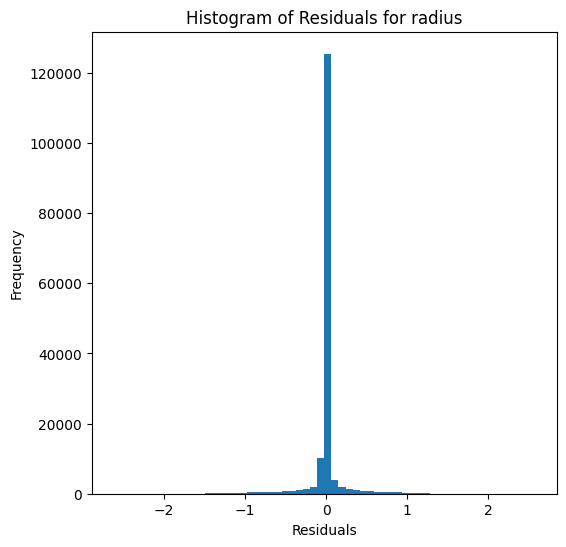

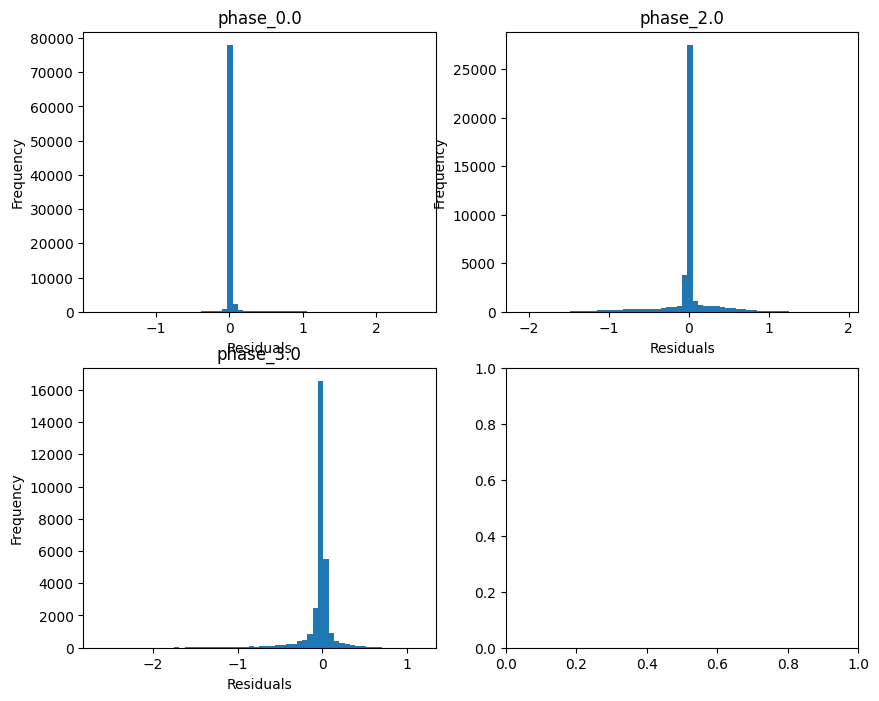

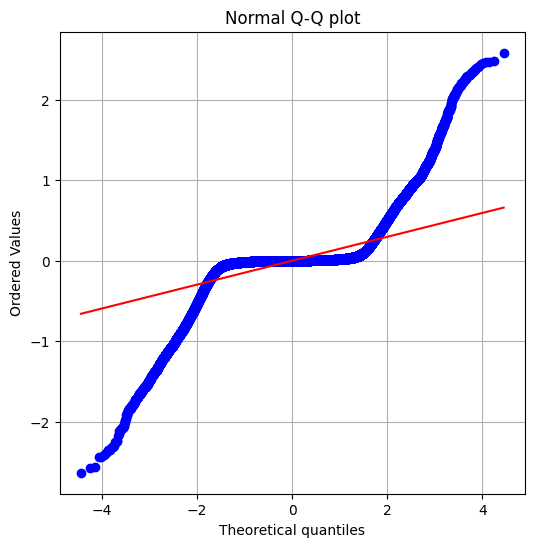

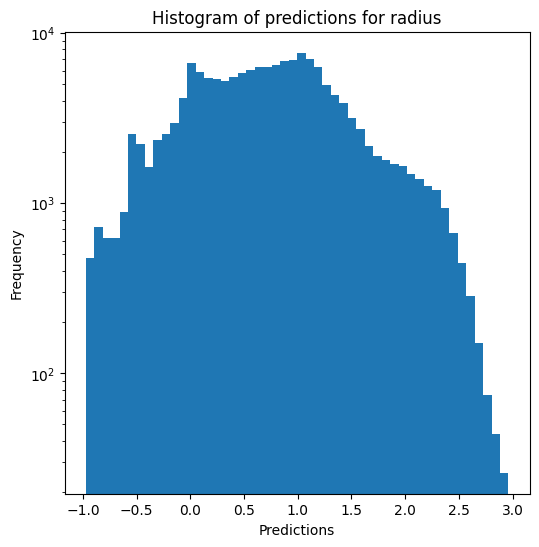

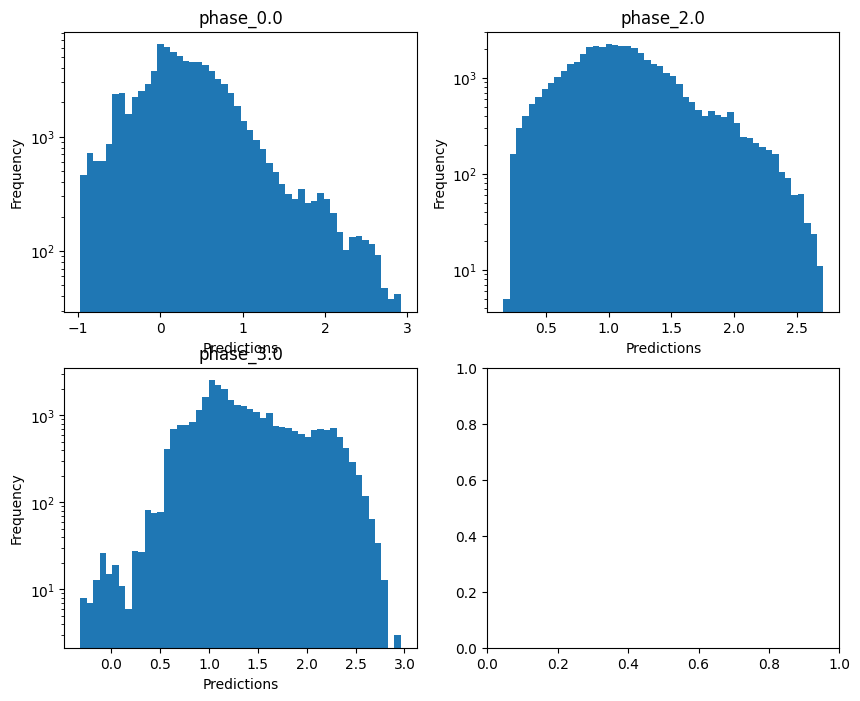

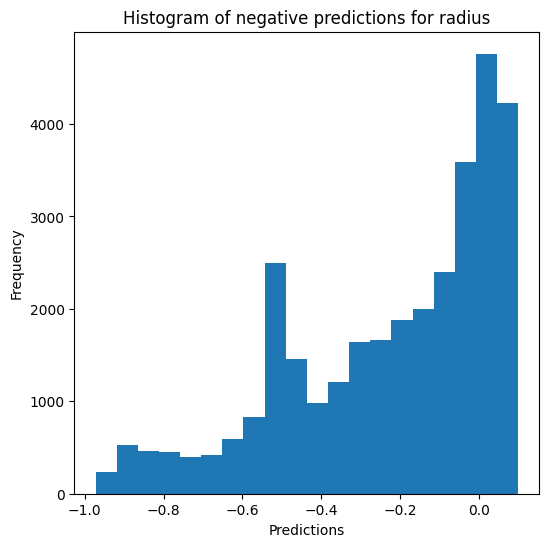

Saving predictions and results...


In [11]:
best_params_RF = {'n_jobs':10, 'n_estimators': 300, 'criterion': 'friedman_mse', 'max_depth': 50, 'min_samples_leaf': 5, 'min_samples_split': 2, 'max_features': 'log2', 'max_leaf_nodes': None}

evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(RandomForestRegressor, X_train_quantile, X_ivs_quantile, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=True, show=True, **best_params_RF)

## KNN

In [12]:
tag = "scale_quantile"

../../../../../../results/model_B/final_models/

scale_quantile train data :
Training the model...
Evaluating predictions...
no negative values

T_eff results for the phase category with a value of 0.0
  value range :  3.3447003632081813 - 4.903113097363014
  RVE :  0.981588320021538
  RMSE :  0.047799933745212
  MAE :  0.009746985528118831
  MedAE :  0.0013780642248952812
  CORR :  0.9908019597255243
  MAX_ER :  0.84147800586365
  Percentiles : 
    75th percentile :  0.0029809135167953027
    90th percentile :  0.00700210791123115
    95th percentile :  0.02180646807004421
    99th percentile :  0.24862809737248037

T_eff results for the phase category with a value of 2.0
  value range :  3.424526073183654 - 4.703420536058761
  RVE :  0.9867282087012967
  RMSE :  0.03646575121647762
  MAE :  0.016615743170268926
  MedAE :  0.0032128198627026094
  CORR :  0.9933536763914955
  MAX_ER :  0.5576884435342575
  Percentiles : 
    75th percentile :  0.013979770503721456
    90th percentile 

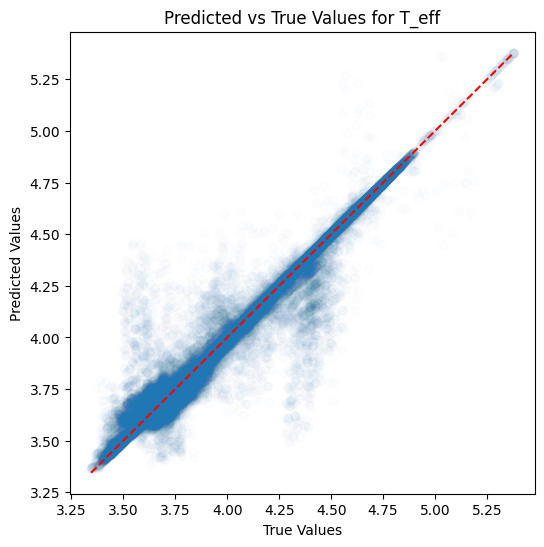

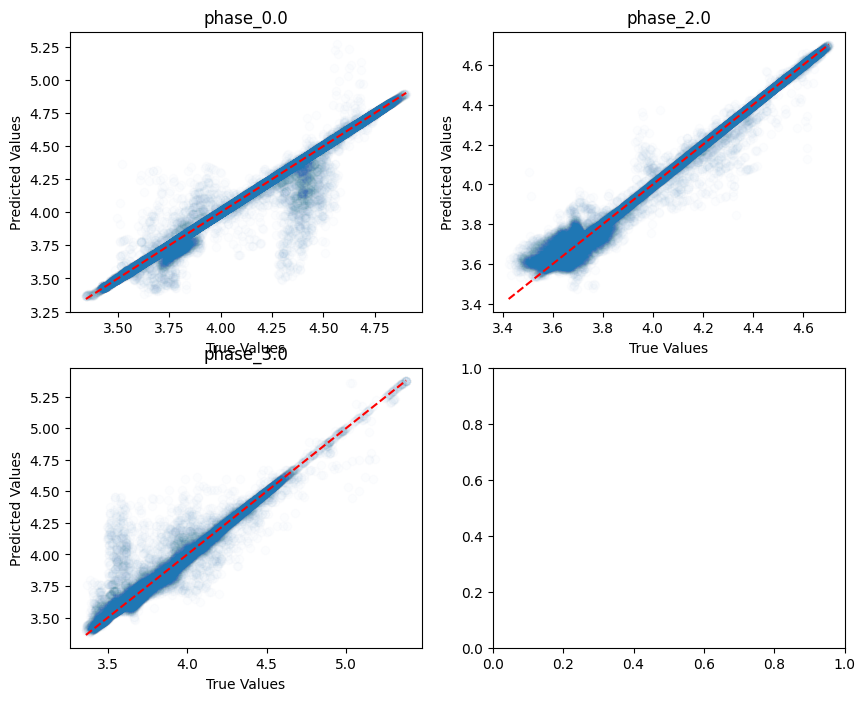

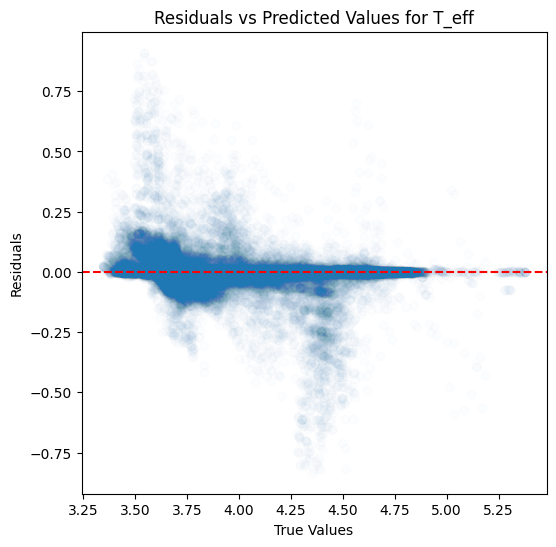

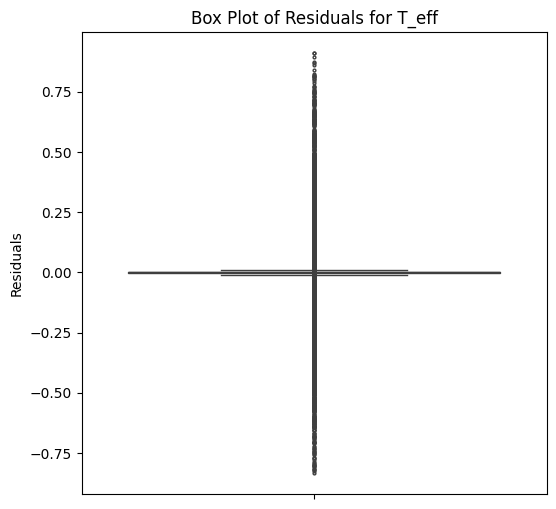

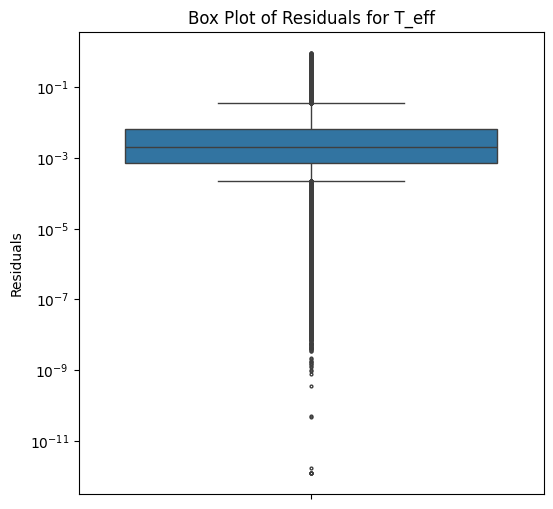

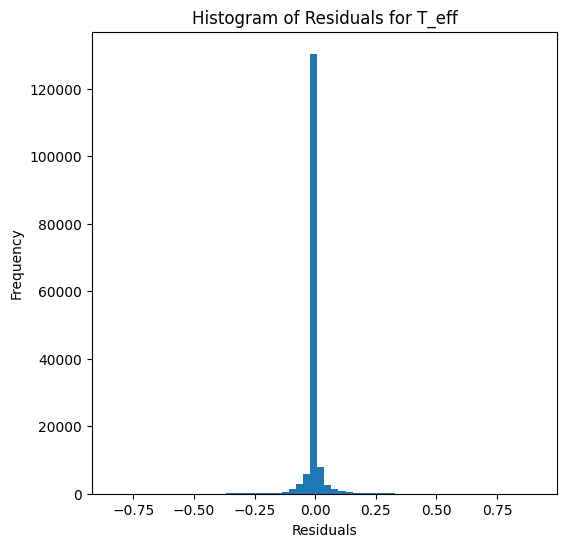

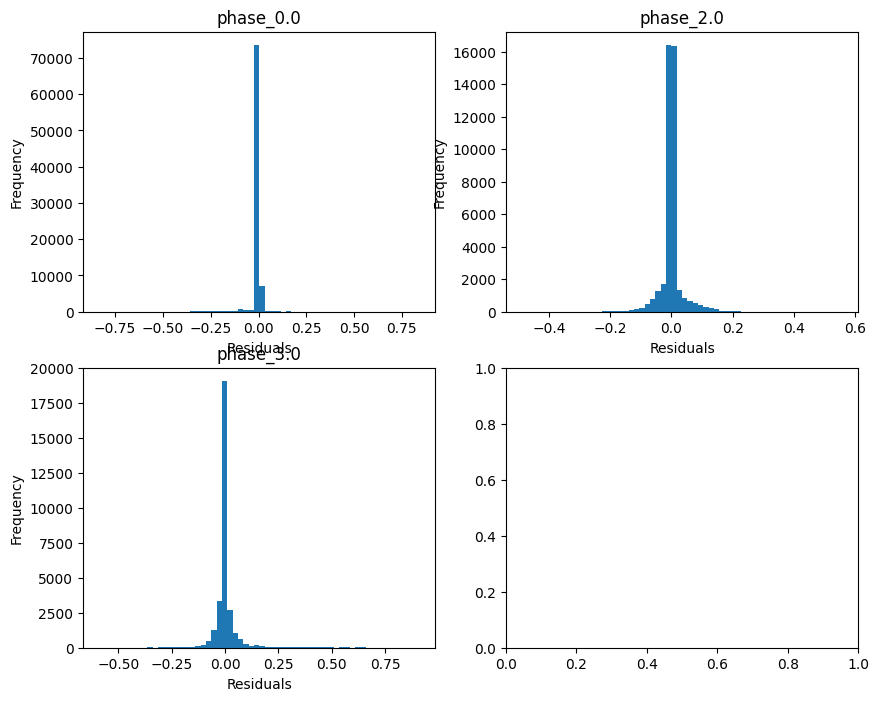

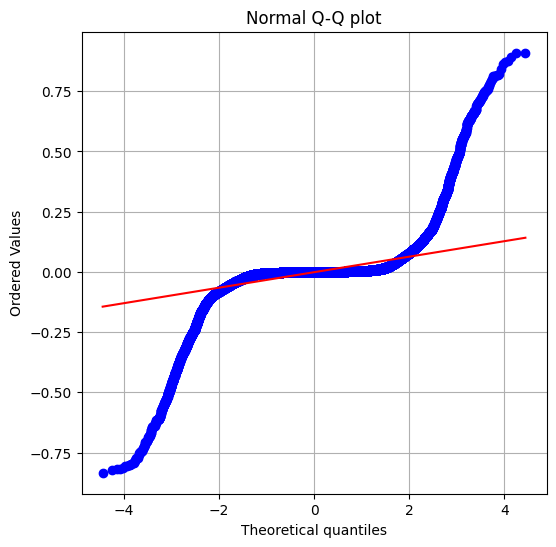

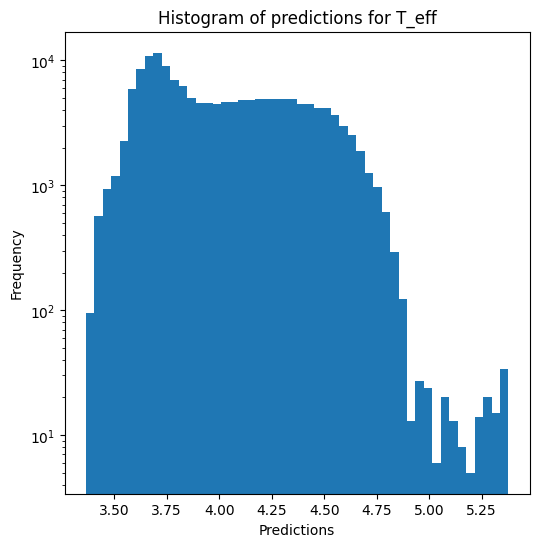

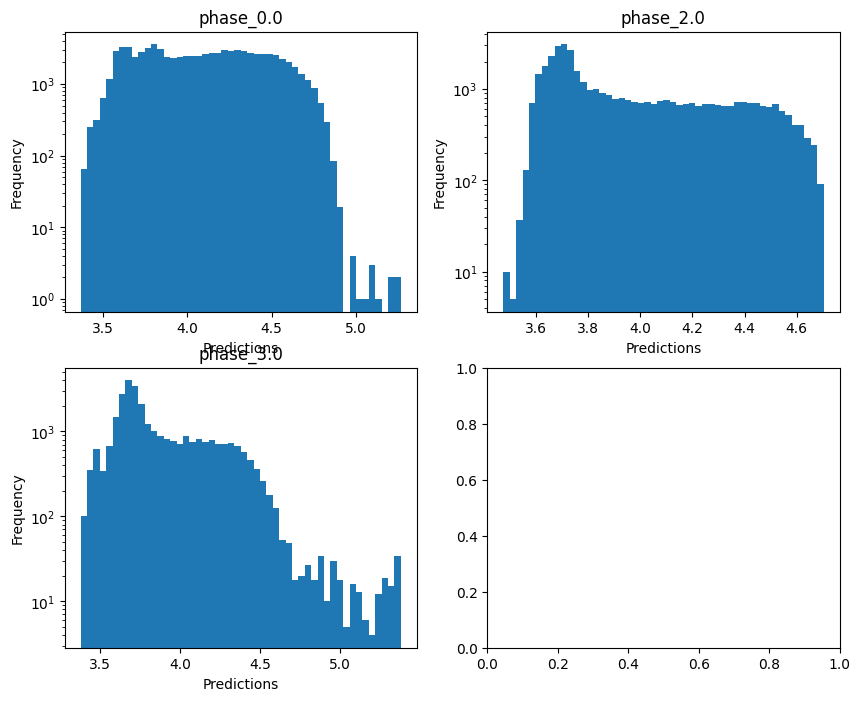


log_g results for the phase category with a value of 0.0
  value range :  -0.5973100835175252 - 5.433094523832443
  RVE :  0.7159689366770554
  RMSE :  0.3344598651912137
  MAE :  0.06402826724000091
  MedAE :  0.003045498053543483
  CORR :  0.8844299251518174
  MAX_ER :  5.476894166411275
  Percentiles : 
    75th percentile :  0.010063614170595092
    90th percentile :  0.025909240092625793
    95th percentile :  0.09355202400655327
    99th percentile :  1.7565045746859644

log_g results for the phase category with a value of 2.0
  value range :  -0.3287802371627256 - 4.403503445748651
  RVE :  0.6430985733359567
  RMSE :  0.544694907264088
  MAE :  0.24273002537050967
  MedAE :  0.015641280632535892
  CORR :  0.8030191290046257
  MAX_ER :  4.002457590878152
  Percentiles : 
    75th percentile :  0.17524770148722468
    90th percentile :  0.9521900393682146
    95th percentile :  1.3997504785852033
    99th percentile :  2.1226086142160137

log_g results for the phase category wit

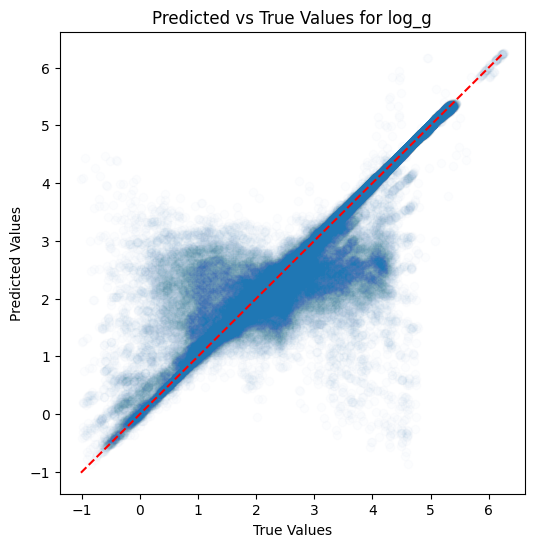

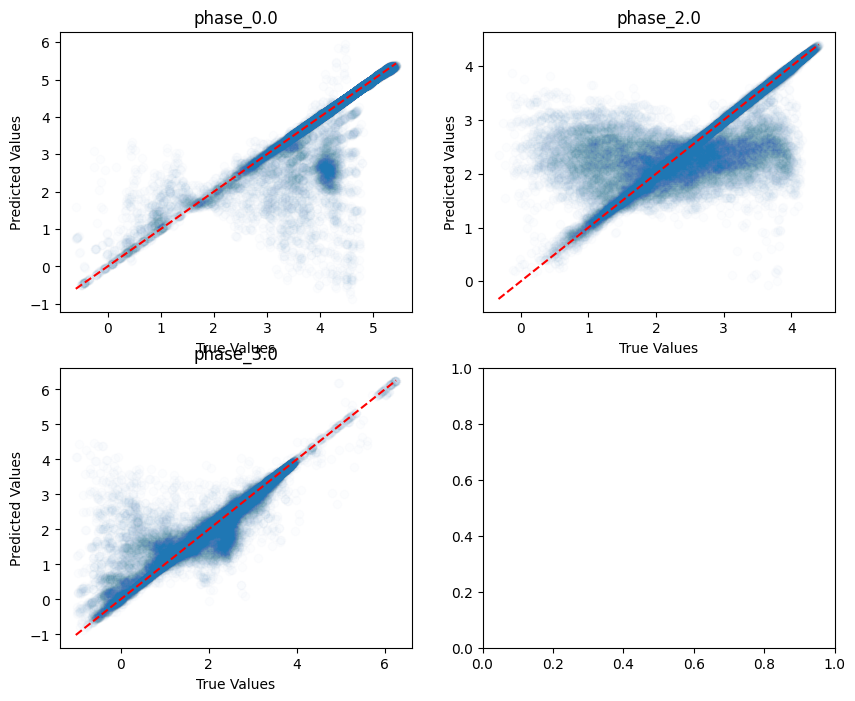

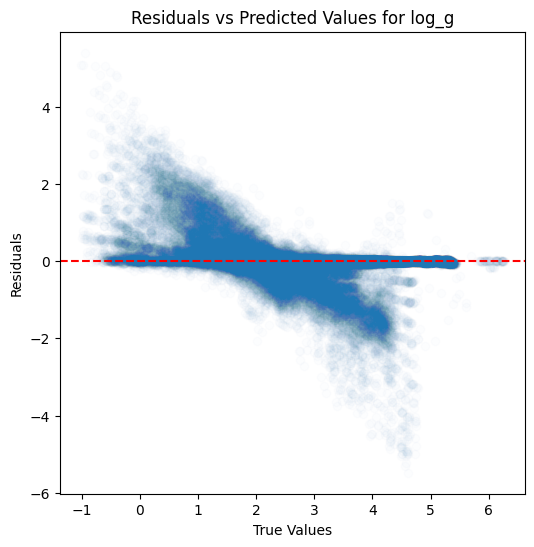

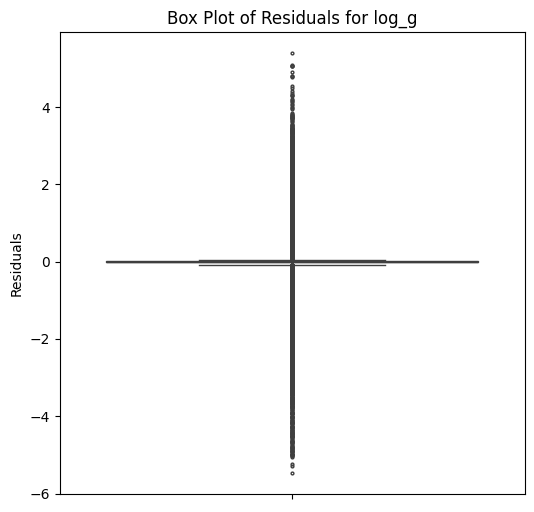

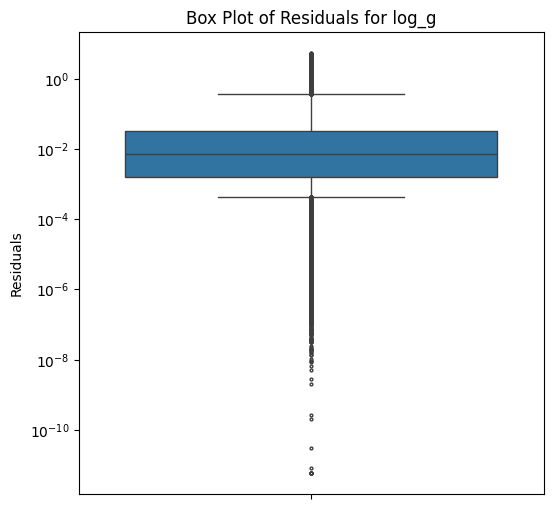

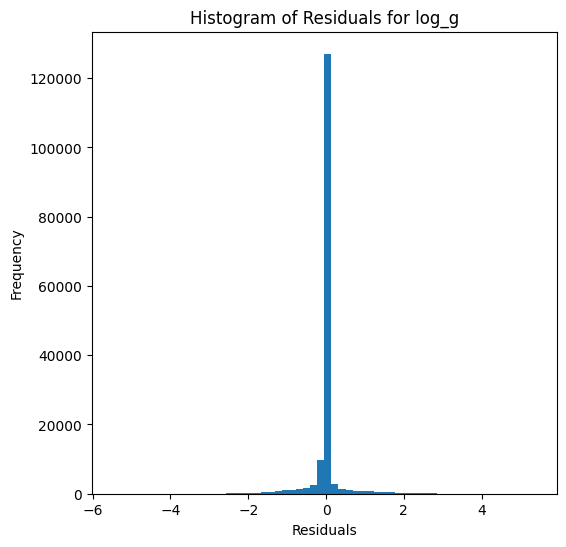

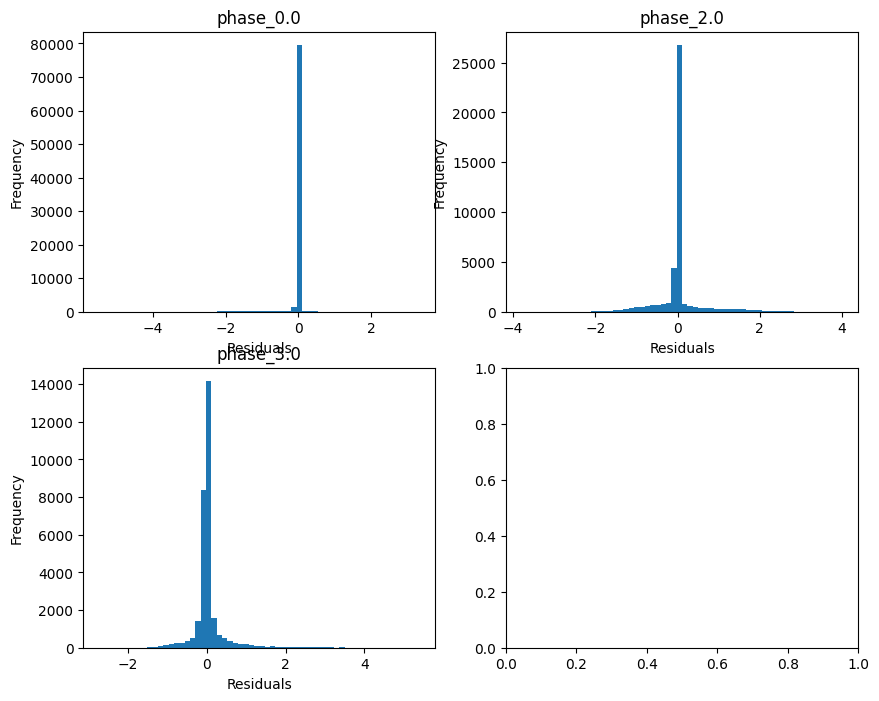

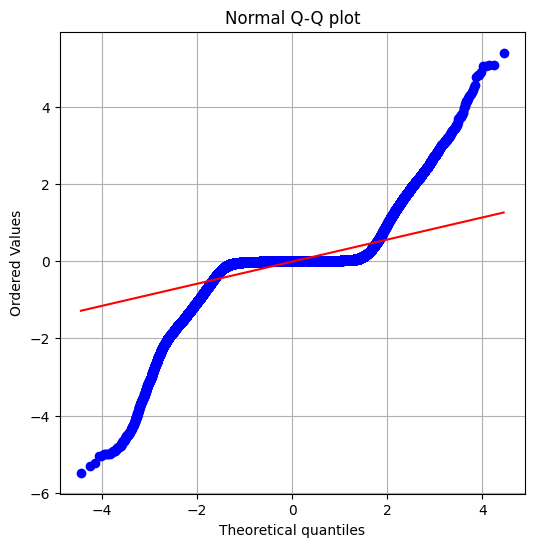

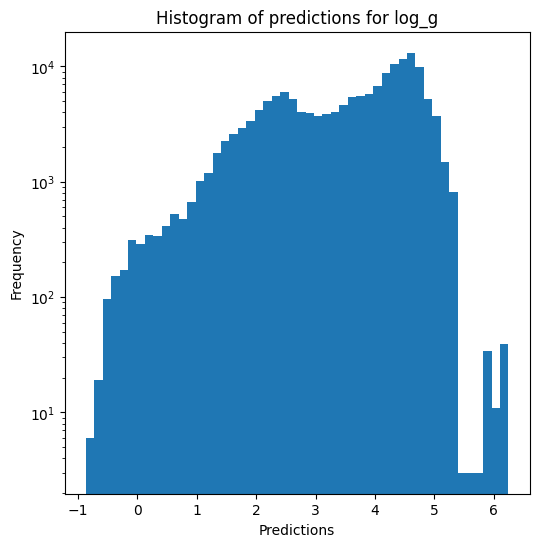

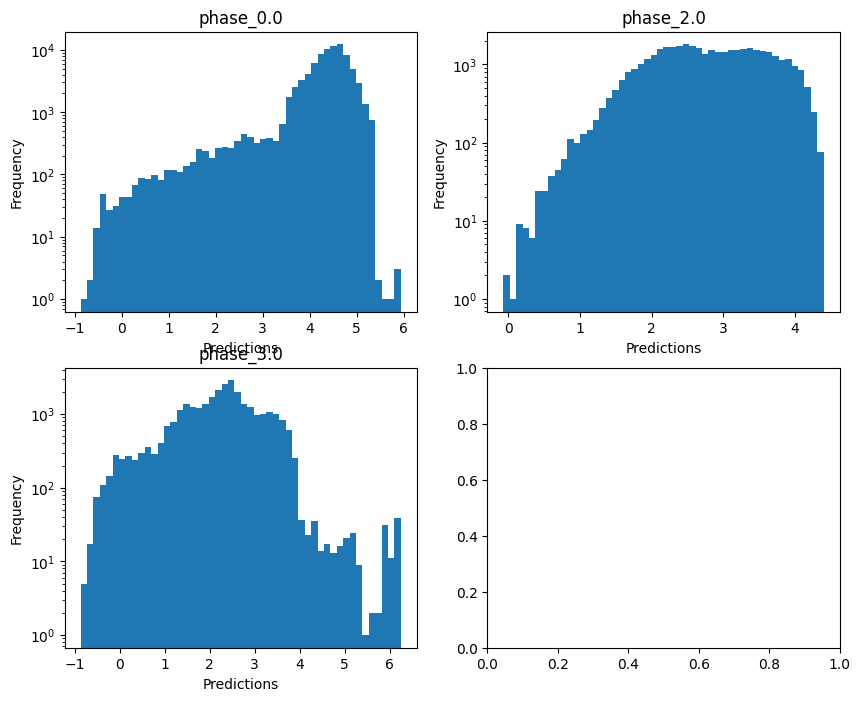

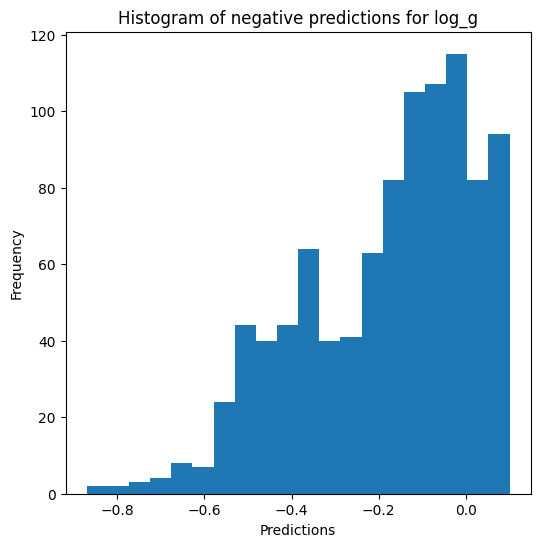


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9144585918506457
  RMSE :  0.16755549723518112
  MAE :  0.03388690794216414
  MedAE :  0.0028397721200067727
  CORR :  0.9597084869807803
  MAX_ER :  2.74065180260365
  Percentiles : 
    75th percentile :  0.007376741531222281
    90th percentile :  0.018599680369935326
    95th percentile :  0.06349354235212157
    99th percentile :  0.8796537494138325

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.692303699443317
  RMSE :  0.2723447515976341
  MAE :  0.1213771999456646
  MedAE :  0.007839684890399656
  CORR :  0.8338805859738134
  MAX_ER :  2.0006517925640495
  Percentiles : 
    75th percentile :  0.08770406841844997
    90th percentile :  0.47610454079769016
    95th percentile :  0.6998659528832155
    99th percentile :  1.0612096597054779

radius results for the phase category

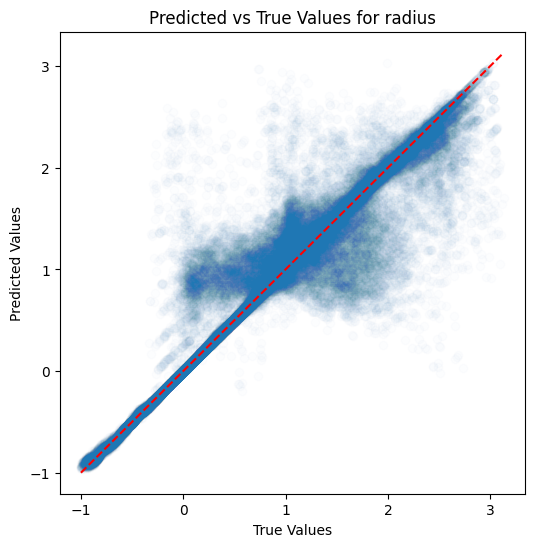

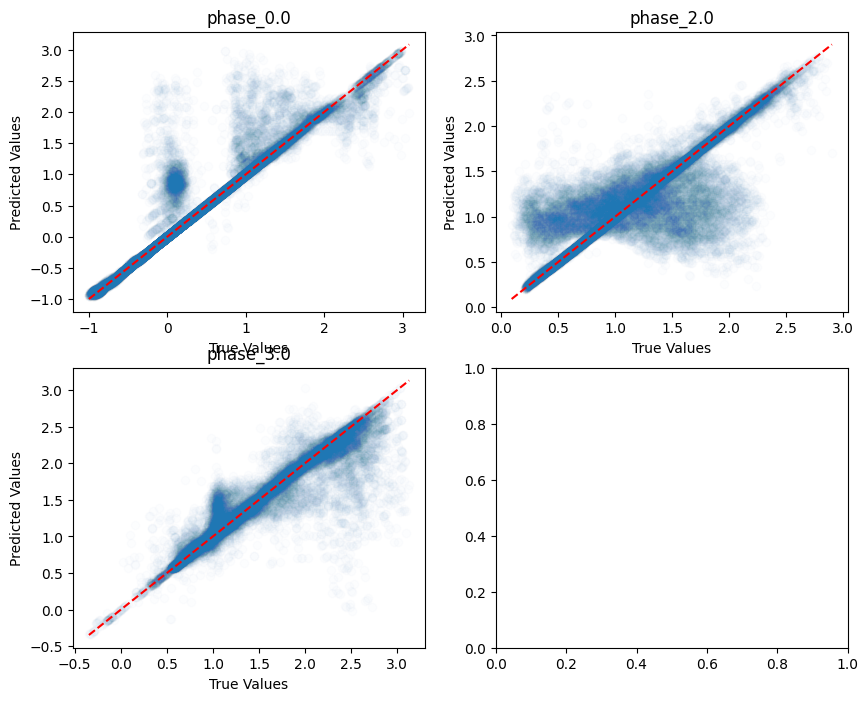

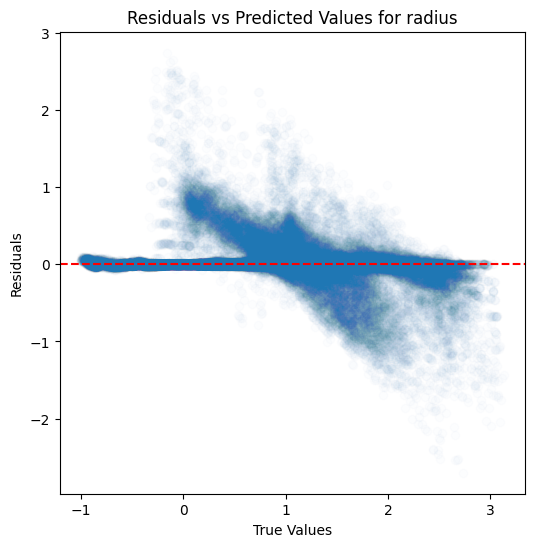

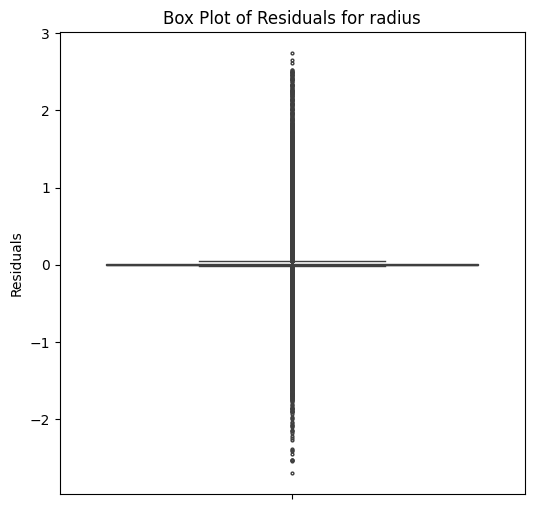

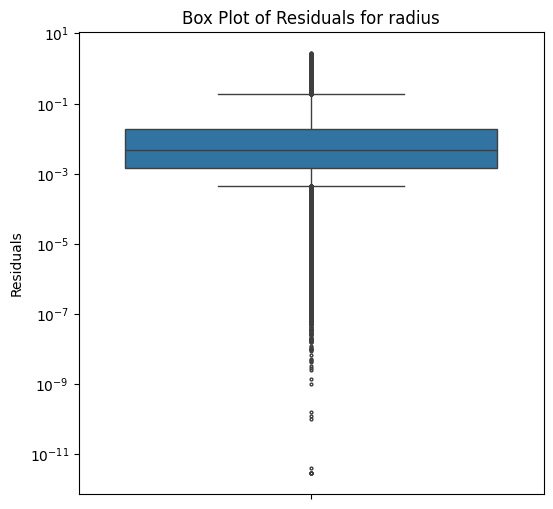

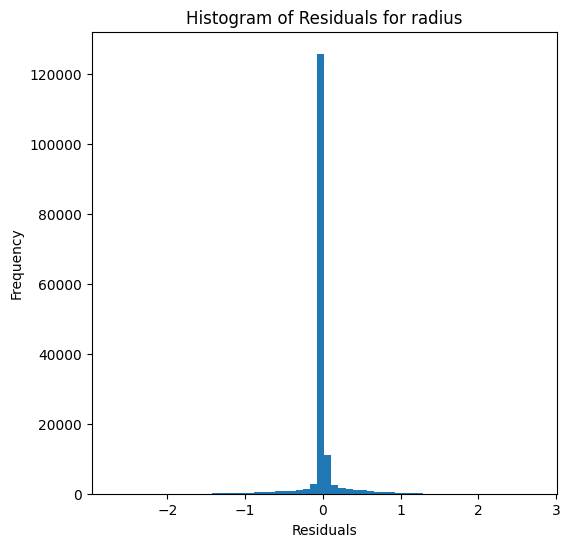

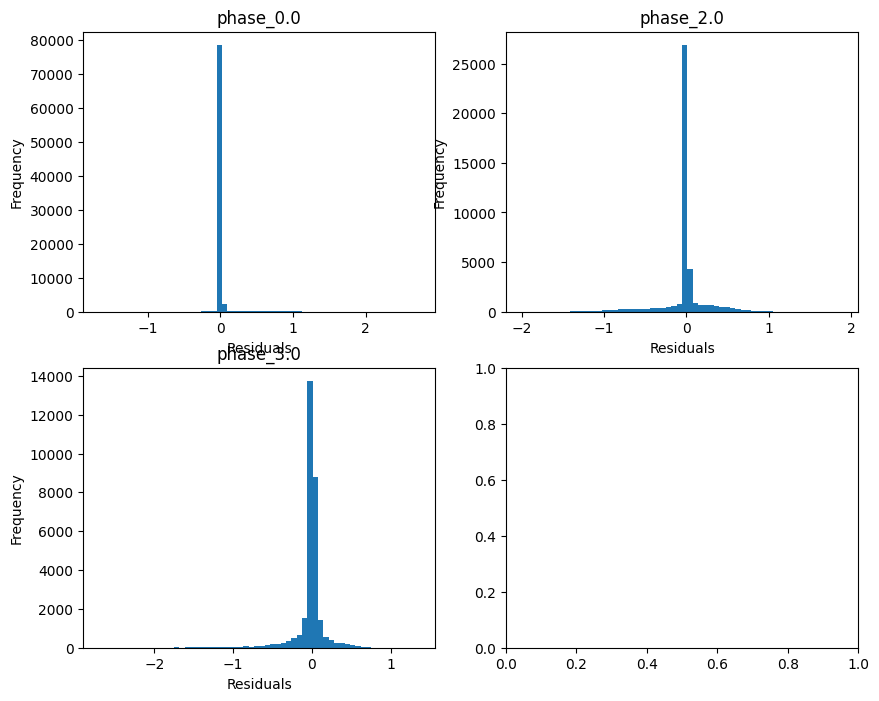

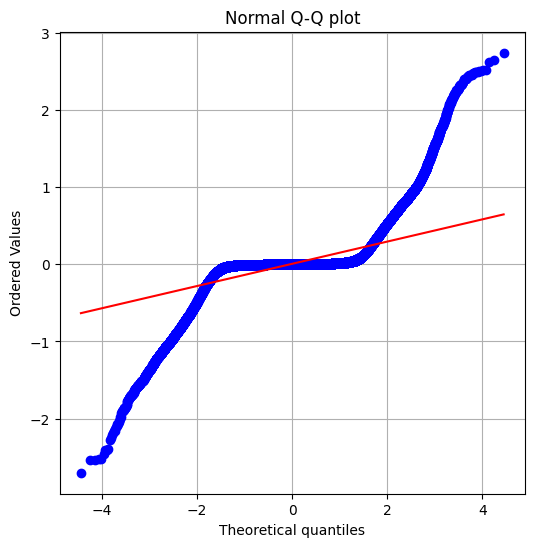

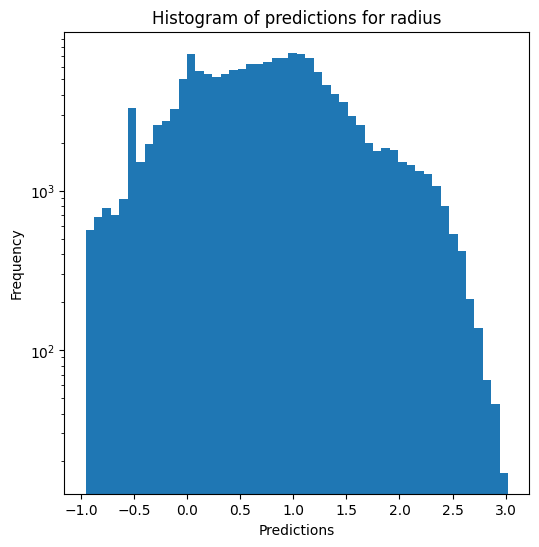

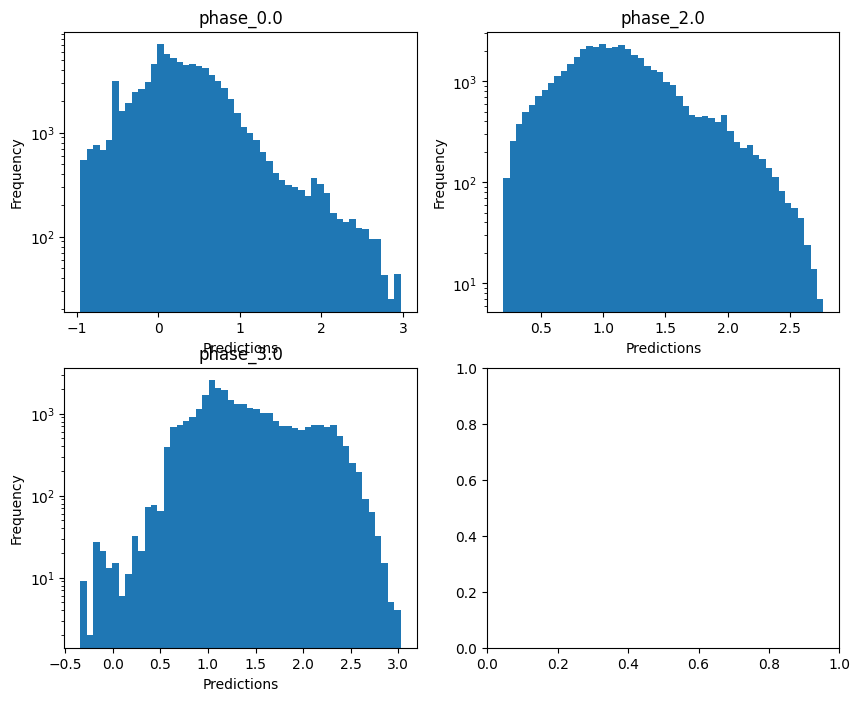

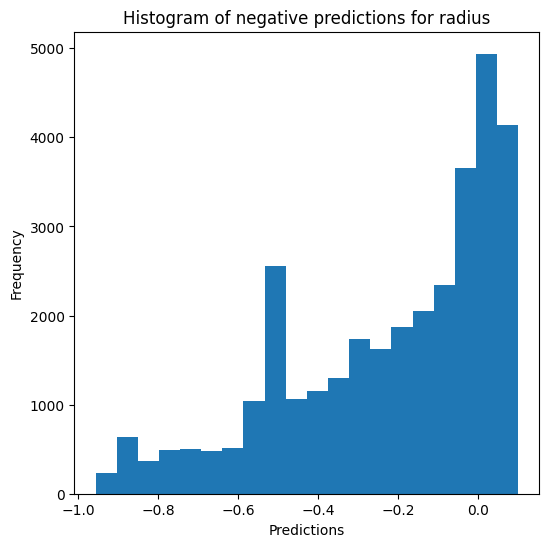

Saving predictions and results...


In [13]:
best_params_KNN = {'n_jobs' : 10, 'algorithm': 'kd_tree', 'leaf_size': 15, 'n_neighbors': 10, 'weights': 'uniform'}

print(path_to_results)
evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(KNeighborsRegressor, X_train_quantile, X_ivs_quantile, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=True, show=True, **best_params_KNN)

# Training the final models

In [9]:
X = np.append(X_train, X_ivs, 0)
X_quantile = np.append(X_train_quantile, X_ivs_quantile, 0)
y = np.append(y_train, y_ivs, 0)

print(X.shape)
print(X_quantile.shape)
print(y.shape)

(630605, 3)
(630605, 3)
(630605, 3)


## Random forest

In [22]:
best_params_RF = {'n_jobs':10, 'n_estimators': 300, 'criterion': 'friedman_mse', 'max_depth': 50, 'min_samples_leaf': 5, 'min_samples_split': 2, 'max_features': 'log2', 'max_leaf_nodes': None}

mdl = RandomForestRegressor(**best_params_RF)
mdl.fit(X_quantile, y)

,n_estimators,300
,criterion,'friedman_mse'
,max_depth,50
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
joblib.dump(mdl, pre_path + path_to_models + "RF_compress_3.pkl", compress=3)
# 1.39 GB
# 52 secondes pour créé le fichier

['../../../../../../model/final_models/model_B/MIST/RF_compress_3.pkl']

## KNN

In [10]:
best_params_KNN = {'n_jobs' : 10, 'algorithm': 'kd_tree', 'leaf_size': 15, 'n_neighbors': 10, 'weights': 'uniform'}

mdl = KNeighborsRegressor(**best_params_KNN)
mdl.fit(X_quantile, y)

,n_neighbors,10
,weights,'uniform'
,algorithm,'kd_tree'
,leaf_size,15
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,10


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "KNN_compress_0.pkl", compress=0)
# 54 MB
# 0.0 secondes pour créé le fichier

['../../../../../../model/final_models/model_B/MIST/KNN_compress_0.pkl']